In [1]:
import sys
from pathlib import Path
import os
import scanpy as sc
import numpy as np

REPO_ROOT = Path("~/scRNA-cross-donor-generalization").expanduser()
os.chdir(REPO_ROOT)
sys.path.append(str(REPO_ROOT / "src"))

In [2]:
### PREPROCESS data for benchmarking
from scrna_benchmark.embedding import (
    compute_hvg_subset,
    compute_pca,
    compute_harmony,
)

adata = sc.read_h5ad("data/PBMC_Stephenson/stephenson_2021_subsampled.h5ad")

# filter to healthy, and subsample to 500 cells per donor
adata = adata[adata.obs["Status"] == "Healthy"].copy()

np.random.seed(42)

cells_to_keep = []

for donor, idx in adata.obs.groupby("patient_id", observed=True).groups.items():
    idx = np.array(list(idx))
    if len(idx) > 500:
        cells_to_keep.extend(np.random.choice(idx, 500, replace=False))
    else:
        cells_to_keep.extend(idx)

adata = adata[cells_to_keep].copy()

print(adata.shape)
print(adata.obs["patient_id"].nunique())

(11290, 16299)
23


In [4]:
# embeddings
adata.raw = adata.copy()

adata = compute_hvg_subset(
    adata,
    n_top_genes=2000,
    batch_key="patient_id",
)

adata = compute_pca(
    adata,
    n_comps=50,
    key_added="X_pca",
    random_state=42,
)

adata.obsm["X_pca_full"] = adata.obsm["X_pca"].copy()
adata.obsm["X_pca"] = adata.obsm["X_pca"][:, :15].copy()

adata = compute_harmony(
    adata,
    batch_col="patient_id",
    basis="X_pca_full",
    key_added="X_harmony",
)

adata.obsm["X_harmony"] = adata.obsm["X_harmony"][:, :15].copy()

print("X_scVI" in adata.obsm) # scVI exists in the original h5ad file, so we don't need to compute it here

2026-05-24 22:17:35,566 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-05-24 22:17:35,567 - harmonypy - INFO -   Parameters:
2026-05-24 22:17:35,567 - harmonypy - INFO -     max_iter_harmony: 10
2026-05-24 22:17:35,568 - harmonypy - INFO -     max_iter_kmeans: 20
2026-05-24 22:17:35,568 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-05-24 22:17:35,569 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-05-24 22:17:35,569 - harmonypy - INFO -     nclust: 100
2026-05-24 22:17:35,570 - harmonypy - INFO -     block_size: 0.05
2026-05-24 22:17:35,570 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
2026-05-24 22:17:35,571 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-05-24 22:17:35,572 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-05-24 22:17:35,572 - harmonypy - INFO -     verbose: True
2026-05-24 22:17:35,573 - harmonypy - INFO -     random

True


In [5]:
adata.write_h5ad("data/PBMC_Stephenson/stephenson_benchmark_ready.h5ad")

Benchmark Set 1: no site covariate in classifier

In [8]:
from scrna_benchmark.config import DatasetConfig
from scrna_benchmark.pipeline import run_dataset_benchmark

adata_path = "data/PBMC_Stephenson/stephenson_benchmark_ready.h5ad"

common_representations = {
    "hvg": "hvg",
    "pca": "X_pca",
    "harmony": "X_harmony",
    "scvi": "X_scVI",
}

config_no_batch = DatasetConfig(
    dataset_name="pbmc_no_batch",
    adata_path=adata_path,
    output_dir="results",

    celltype_col="cell_type",
    donor_col="patient_id",
    batch_col=None,
    group_col="Site",

    representations=common_representations,

    min_cells=200,
    min_donors=5,

    run_random_split=True,
    run_donor_cv=True,

    run_group_transfer=True,
    group_transfer_pairs=[
        ("Cambridge", "Ncl"),
        ("Ncl", "Cambridge"),
    ],

    run_donor_ablation=True,
    donor_ablation_k_values=[3, 5, 8, 10, 15, 20],
    donor_ablation_n_repeats=5,

    test_size=0.2,
    n_folds=5,
    random_state=42,

    save_filtered_adata=False,
    verbose=True,
)

outputs_no_batch = run_dataset_benchmark(config_no_batch)

Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running donor_cv: hvg (hvg)
Running donor_cv: pca (X_pca)
Running donor_cv: harmony (X_harmony)
Running donor_cv: scvi (X_scVI)
Running group transfer Cambridge_to_Ncl: hvg (hvg)
Running group transfer Cambridge_to_Ncl: pca (X_pca)
Running group transfer Cambridge_to_Ncl: harmony (X_harmony)
Running group transfer Cambridge_to_Ncl: scvi (X_scVI)
Running group transfer Ncl_to_Cambridge: hvg (hvg)
Running group transfer Ncl_to_Cambridge: pca (X_pca)
Running group transfer Ncl_to_Cambridge: harmony (X_harmony)
Running group transfer Ncl_to_Cambridge: scvi (X_scVI)
Running group transfer Ncl_to_Cambridge: hvg (hvg)
Running group transfer Ncl_to_Cambridge: pca (X_pca)
Running group transfer Ncl_to_Cambridge: harmony (X_harmony)
Running group transfer Ncl_to_Cambridge: scvi (X_scVI)
Running group transfer Cambridge_to_Ncl: hvg (hvg)
Running group tra

Benchmark set 2: site covariate considered in classifier

In [13]:
config_with_site = DatasetConfig(
    dataset_name="pbmc_with_site_covariate",
    adata_path=adata_path,
    output_dir="results",

    celltype_col="cell_type",
    donor_col="patient_id",
    batch_col="Site",
    group_col="Site",

    representations=common_representations,

    min_cells=200,
    min_donors=5,

    run_random_split=True,
    run_donor_cv=True,

    # keep these off for the covariate sensitivity run
    run_group_transfer=False,
    run_donor_ablation=False,

    test_size=0.2,
    n_folds=5,
    random_state=42,

    save_filtered_adata=False,
    verbose=True,
)

outputs_with_site = run_dataset_benchmark(config_with_site)

Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running random_split: scanorama (X_scanorama)
Running donor_cv: hvg (hvg)
Running donor_cv: pca (X_pca)
Running donor_cv: harmony (X_harmony)
Running donor_cv: scvi (X_scVI)
Running donor_cv: scanorama (X_scanorama)


In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Change this to your actual main-run folder
result_dir = Path("results/pbmc_no_batch")

random_path = result_dir / "random_split" / "metrics.csv"
donor_path = result_dir / "donor_cv" / "metrics.csv"

figures_dir = result_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

random_df = pd.read_csv(random_path)
donor_df = pd.read_csv(donor_path)

print("Random split:")
display(random_df)

print("Donor CV:")
display(donor_df)

Random split:


,scheme,representation,macro_f1,accuracy,n_cells_used,n_classes_used,batch_covariate,n_batch_features
0,random_split,hvg,0.789520,0.817013,10107,13,NaN,0
1,random_split,pca,0.789837,0.822948,10107,13,NaN,0
2,random_split,harmony,0.755549,0.789812,10107,13,NaN,0
3,random_split,scvi,0.757488,0.791790,10107,13,NaN,0


Donor CV:


,scheme,representation,macro_f1_mean,macro_f1_std,accuracy_mean,accuracy_std,n_folds,mean_train_cells,mean_test_cells,mean_n_classes_used,batch_covariate,mean_n_batch_features
0,donor_cv,hvg,0.765295,0.019322,0.802587,0.023419,5,8085.6,2021.4,13.0,NaN,0.0
1,donor_cv,pca,0.775636,0.031406,0.813954,0.037290,5,8085.6,2021.4,13.0,NaN,0.0
2,donor_cv,harmony,0.748225,0.030225,0.788531,0.035855,5,8085.6,2021.4,13.0,NaN,0.0
3,donor_cv,scvi,0.744218,0.034787,0.787228,0.040640,5,8085.6,2021.4,13.0,NaN,0.0


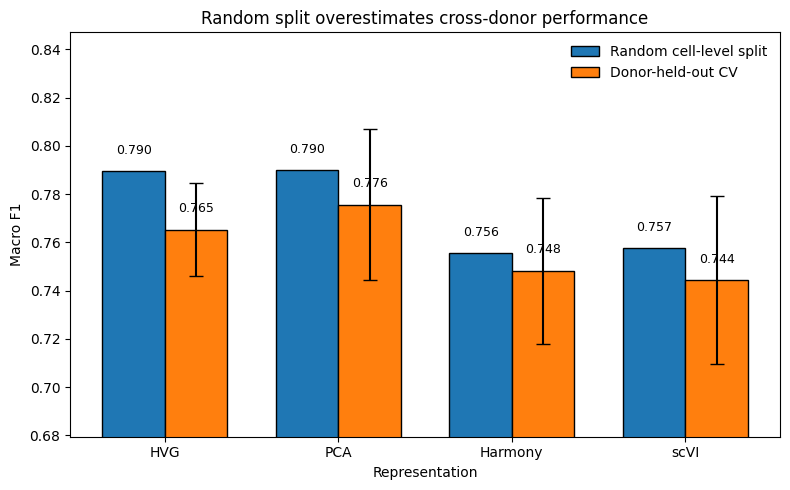

Saved: results/pbmc_no_batch/figures/panel_2B_random_vs_donor_cv_no_scanorama.png


In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

result_dir = Path("results/pbmc_no_batch")  # change if needed
figures_dir = result_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

random_df = pd.read_csv(result_dir / "random_split" / "metrics.csv")
donor_df = pd.read_csv(result_dir / "donor_cv" / "metrics.csv")

rep_order = ["hvg", "pca", "harmony", "scvi"]
rep_labels = {
    "hvg": "HVG",
    "pca": "PCA",
    "harmony": "Harmony",
    "scvi": "scVI",
}

def clean_rep(x):
    return {
        "hvg": "hvg",
        "pca": "pca",
        "harmony": "harmony",
        "scvi": "scvi",
        "X_pca": "pca",
        "X_harmony": "harmony",
        "X_scVI": "scvi",
    }.get(x, x)

random_df["rep_clean"] = random_df["representation"].map(clean_rep)
donor_df["rep_clean"] = donor_df["representation"].map(clean_rep)

common_reps = [
    rep for rep in rep_order
    if rep in set(random_df["rep_clean"]) and rep in set(donor_df["rep_clean"])
]

random_plot = random_df.set_index("rep_clean").loc[common_reps]
donor_plot = donor_df.set_index("rep_clean").loc[common_reps]

x = np.arange(len(common_reps))
width = 0.36

fig, ax = plt.subplots(figsize=(8, 5))

bars_random = ax.bar(
    x - width / 2,
    random_plot["macro_f1"],
    width,
    label="Random cell-level split",
    edgecolor="black",
)

bars_donor = ax.bar(
    x + width / 2,
    donor_plot["macro_f1_mean"],
    width,
    yerr=donor_plot["macro_f1_std"],
    capsize=5,
    label="Donor-held-out CV",
    edgecolor="black",
)

ax.set_xticks(x)
ax.set_xticklabels([rep_labels[r] for r in common_reps])
ax.set_xlabel("Representation")
ax.set_ylabel("Macro F1")
ax.set_title("Random split overestimates cross-donor performance")
ax.legend(frameon=False)

ymax = max(
    random_plot["macro_f1"].max(),
    (donor_plot["macro_f1_mean"] + donor_plot["macro_f1_std"]).max(),
)
ymin = min(
    random_plot["macro_f1"].min(),
    (donor_plot["macro_f1_mean"] - donor_plot["macro_f1_std"]).min(),
)
ax.set_ylim(ymin - 0.03, ymax + 0.04)

for bars in [bars_random, bars_donor]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.006,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()

out_png = figures_dir / "panel_2B_random_vs_donor_cv_no_scanorama.png"
# plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_png}")

In [11]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import scanpy as sc

# =========================
# CHANGE THESE TWO PATHS
# =========================
result_dir = Path("results/pbmc_no_batch")  # folder used for your current plot
og_adata_path = Path("archive/data/adata_full_celltypes.h5ad")

# This will be read from config.json if possible
config_path = result_dir / "config.json"

print("=== 1. What result folder am I plotting? ===")
print("result_dir:", result_dir.resolve())
print("random metrics exists:", (result_dir / "random_split" / "metrics.csv").exists())
print("donor metrics exists:", (result_dir / "donor_cv" / "metrics.csv").exists())
print("config exists:", config_path.exists())

print("\n=== 2. Config used for this run ===")
if config_path.exists():
    with open(config_path) as f:
        cfg = json.load(f)
    print("dataset_name:", cfg.get("dataset_name"))
    print("adata_path:", cfg.get("adata_path"))
    print("batch_col:", cfg.get("batch_col"))
    print("group_col:", cfg.get("group_col"))
    print("representations:", cfg.get("representations"))
    current_adata_path = Path(cfg["adata_path"])
else:
    raise FileNotFoundError(f"Missing config.json at {config_path}")

print("\n=== 3. Current metrics ===")
random_df = pd.read_csv(result_dir / "random_split" / "metrics.csv")
donor_df = pd.read_csv(result_dir / "donor_cv" / "metrics.csv")

display(random_df)
display(donor_df)

print("\n=== 4. Load OG and current AnnData ===")
og = sc.read_h5ad(og_adata_path)
new = sc.read_h5ad(current_adata_path)

print("OG path:", og_adata_path)
print("New path:", current_adata_path)
print("OG shape:", og.shape)
print("New shape:", new.shape)

print("\n=== 5. Metadata identity checks ===")
print("same obs_names:", np.array_equal(og.obs_names.to_numpy(), new.obs_names.to_numpy()))
print("same var_names:", np.array_equal(og.var_names.to_numpy(), new.var_names.to_numpy()))

for col in ["cell_type", "patient_id", "Site"]:
    print(f"\nColumn: {col}")
    print("  in OG:", col in og.obs.columns)
    print("  in New:", col in new.obs.columns)
    if col in og.obs.columns and col in new.obs.columns:
        print("  same values:", np.array_equal(
            og.obs[col].astype(str).to_numpy(),
            new.obs[col].astype(str).to_numpy()
        ))
        print("  OG nunique:", og.obs[col].astype(str).nunique())
        print("  New nunique:", new.obs[col].astype(str).nunique())

print("\n=== 6. Representation identity checks ===")
for key in ["X_pca", "X_harmony", "X_scVI", "X_scanorama"]:
    print(f"\n{key}:")
    print("  in OG:", key in og.obsm)
    print("  in New:", key in new.obsm)
    if key in og.obsm and key in new.obsm:
        print("  OG shape:", og.obsm[key].shape)
        print("  New shape:", new.obsm[key].shape)
        same_shape = og.obsm[key].shape == new.obsm[key].shape
        print("  same shape:", same_shape)
        if same_shape:
            print("  allclose:", np.allclose(og.obsm[key], new.obsm[key]))
            print("  max abs diff:", np.max(np.abs(og.obsm[key] - new.obsm[key])))

print("\n=== 7. HVG / X identity check ===")
print("OG X shape:", og.X.shape)
print("New X shape:", new.X.shape)
if og.X.shape == new.X.shape:
    X_og = og.X.toarray() if hasattr(og.X, "toarray") else np.asarray(og.X)
    X_new = new.X.toarray() if hasattr(new.X, "toarray") else np.asarray(new.X)
    print("X allclose:", np.allclose(X_og, X_new))
    print("X max abs diff:", np.max(np.abs(X_og - X_new)))

print("\n=== 8. Filtering preview ===")
def filtering_summary(adata, celltype_col="cell_type", donor_col="patient_id", min_cells=200, min_donors=5):
    counts = adata.obs[celltype_col].astype(str).value_counts()
    ct_donor = pd.crosstab(
        adata.obs[celltype_col].astype(str),
        adata.obs[donor_col].astype(str),
    )
    donor_counts = (ct_donor > 0).sum(axis=1)
    donor_counts = donor_counts.loc[counts.index]
    keep = (counts >= min_cells) & (donor_counts >= min_donors)
    return pd.DataFrame({
        "cell_type": counts.index,
        "n_cells": counts.values,
        "n_donors": donor_counts.values,
        "keep": keep.values,
    })

og_support = filtering_summary(og)
new_support = filtering_summary(new)

print("OG kept:", og_support["keep"].sum(), "filtered cells:", og_support.loc[og_support["keep"], "n_cells"].sum())
print("New kept:", new_support["keep"].sum(), "filtered cells:", new_support.loc[new_support["keep"], "n_cells"].sum())

compare_support = og_support.merge(
    new_support,
    on="cell_type",
    how="outer",
    suffixes=("_og", "_new"),
)
compare_support["same_keep"] = compare_support["keep_og"] == compare_support["keep_new"]

display(compare_support[~compare_support["same_keep"]])

=== 1. What result folder am I plotting? ===
result_dir: /users/xchen5/scRNA-cross-donor-generalization/results/pbmc_no_batch
random metrics exists: True
donor metrics exists: True
config exists: True

=== 2. Config used for this run ===
dataset_name: pbmc_no_batch
adata_path: data/PBMC_Stephenson/stephenson_benchmark_ready.h5ad
batch_col: None
group_col: Site
representations: {'hvg': 'hvg', 'pca': 'X_pca', 'harmony': 'X_harmony', 'scvi': 'X_scVI'}

=== 3. Current metrics ===


,scheme,representation,macro_f1,accuracy,n_cells_used,n_classes_used,batch_covariate,n_batch_features
0,random_split,hvg,0.789520,0.817013,10107,13,NaN,0
1,random_split,pca,0.789837,0.822948,10107,13,NaN,0
2,random_split,harmony,0.755549,0.789812,10107,13,NaN,0
3,random_split,scvi,0.757488,0.791790,10107,13,NaN,0


,scheme,representation,macro_f1_mean,macro_f1_std,accuracy_mean,accuracy_std,n_folds,mean_train_cells,mean_test_cells,mean_n_classes_used,batch_covariate,mean_n_batch_features
0,donor_cv,hvg,0.765295,0.019322,0.802587,0.023419,5,8085.6,2021.4,13.0,NaN,0.0
1,donor_cv,pca,0.775636,0.031406,0.813954,0.037290,5,8085.6,2021.4,13.0,NaN,0.0
2,donor_cv,harmony,0.748225,0.030225,0.788531,0.035855,5,8085.6,2021.4,13.0,NaN,0.0
3,donor_cv,scvi,0.744218,0.034787,0.787228,0.040640,5,8085.6,2021.4,13.0,NaN,0.0



=== 4. Load OG and current AnnData ===
OG path: archive/data/adata_full_celltypes.h5ad
New path: data/PBMC_Stephenson/stephenson_benchmark_ready.h5ad
OG shape: (11290, 2000)
New shape: (11290, 2000)

=== 5. Metadata identity checks ===
same obs_names: True
same var_names: True

Column: cell_type
  in OG: True
  in New: True
  same values: True
  OG nunique: 41
  New nunique: 41

Column: patient_id
  in OG: True
  in New: True
  same values: True
  OG nunique: 23
  New nunique: 23

Column: Site
  in OG: True
  in New: True
  same values: True
  OG nunique: 2
  New nunique: 2

=== 6. Representation identity checks ===

X_pca:
  in OG: True
  in New: True
  OG shape: (11290, 15)
  New shape: (11290, 15)
  same shape: True
  allclose: False
  max abs diff: 7.2300434e-05

X_harmony:
  in OG: True
  in New: True
  OG shape: (11290, 15)
  New shape: (11290, 15)
  same shape: True
  allclose: False
  max abs diff: 0.00012755394

X_scVI:
  in OG: True
  in New: True
  OG shape: (11290, 10)
  N

,cell_type,n_cells_og,n_donors_og,keep_og,n_cells_new,n_donors_new,keep_new,same_keep
